### <center><b>Mineração e Análise de Séries Temporais</b></center>
#### <center>Prof. Vinicius M. A. Souza</center>

### <center><b>Experimento de Coleta de Dados e Análise de Séries Temporais</b></center>
#### <center><b>(Avaliação de gestos manuais de esquerda, direita e para cima capturados via celular)</b></center>
#### <center>Cássio Augusto Rúbio</center>

In [ ]:
%pip install -q -U aeon[all_extras]

In [58]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay, confusion_matrix, precision_score,
    recall_score, f1_score, classification_report, accuracy_score
)

# Classificadores monolíticos
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Ensembles
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
warnings.filterwarnings('ignore')

## <b>Base de Dados</b>
Carga da base de dados do problema, representada aqui por **X** e **y**, onde:
- **X**: *array* contendo **N** instâncias com **M** atributos de entrada do problema;
- **y**: *array* contendo o rótulo (atributo-alvo) de cada instância de **X**.

In [59]:
# Base de dados do experimento
URL_BASE_DADOS = "https://raw.githubusercontent.com/casrubio/Gestos-esquerda-direita-cima/refs/heads/main/Gestos/base_dados/gestos_3_classes.csv"

# Carrega a base de dados
df = pd.read_csv(URL_BASE_DADOS, sep=';')

# Remove as colunas irrelevantes no contexto de estudo
df.drop(["gesto", "nome_classe", "duracao", "numero_amostras"], axis=1, inplace=True)

# Separa atributos de entrada em X e as classes em y
X = df.iloc[:,0:48]
y = df.iloc[:,48]

print("Formato de X: ", X.shape)
print("Formato de y: ", y.shape)

Formato de X:  (210, 48)
Formato de y:  (210,)


### <b>Atributos da Base de Dados:</b>
* **Acelerômetro**:
  * ax_media; ax_std; ax_min; ax_max; ax_amplitude; ax_rms; ax_mediana; ax_energia;
  * ay_media; ay_std; ay_min; ay_max; ay_amplitude; ay_rms; ay_mediana; ay_energia;
  * az_media; az_std; az_min; az_max; az_amplitude; az_rms; az_mediana; az_energia;
* **Giroscópio**:
  * gx_media; gx_std; gx_min; gx_max; gx_amplitude; gx_rms; gx_mediana; gx_energia;
  * gy_media; gy_std; gy_min; gy_max; gy_amplitude; gy_rms; gy_mediana; gy_energia;
  * gz_media; gz_std; gz_min; gz_max; gz_amplitude; gz_rms; gz_mediana; gz_energia;
* classe – rótulo do gesto: 0 (esquerda), 1 (direita) e 2 (cima).

**Significados dos atributos iniciados pelos prefixos** *ax*, *ay*, *az*, *gx*, *gy* **e** *gz*:
* _media_ – média dos valores	no eixo;
* _std_ – desvio-padrão;
* _min_ – valor mínimo do sinal;
* _max_ – valor máximo do sinal;
* _amplitude_ – amplitude do sinal;
* _rms_ – _Root Mean Square_ – intensidade média do sinal;
* _mediana_ – mediana;
* _energia_ – intensidade acumulada do sinal.


In [60]:
# Visualização das 10 linhas iniciais da base de dados
df.head(10)

,ax_media,ax_std,ax_min,ax_max,ax_amplitude,ax_rms,ax_mediana,ax_energia,ay_media,ay_std,...,gy_energia,gz_media,gz_std,gz_min,gz_max,gz_amplitude,gz_rms,gz_mediana,gz_energia,classe
0,-0.407657,1.522262,-3.120241,3.881158,7.001399,1.575901,-0.406780,3712.779490,1.414816,0.377723,...,109.590130,0.051262,0.418123,-0.853531,0.947299,1.800829,0.421253,-0.004429,265.294367,0
1,-0.323467,1.361594,-3.684947,2.464607,6.149554,1.399488,-0.289532,3012.277415,1.325148,0.293792,...,103.158680,-0.067934,0.464503,-0.952491,0.836121,1.788612,0.469444,-0.072846,338.941327,0
2,-0.376448,1.239091,-2.871387,2.866601,5.737989,1.295013,-0.358923,2748.700274,1.265883,0.290555,...,120.008392,0.030820,0.428088,-0.857196,0.724944,1.582140,0.429196,0.037110,301.919310,0
3,-0.564964,0.967816,-2.612962,1.713261,4.326223,1.120648,-0.631705,2310.768582,0.915442,0.314116,...,71.053929,0.029066,0.325869,-0.728914,0.589332,1.318246,0.327163,0.007789,196.945699,0
4,-0.322824,1.041464,-2.455036,2.890530,5.345566,1.090350,-0.507278,1871.271051,0.972921,0.353866,...,73.871989,-0.073579,0.270092,-0.621402,0.520915,1.142317,0.279935,-0.064294,123.344335,0
5,-0.337904,1.001851,-2.373680,2.139184,4.512864,1.057301,-0.373280,1903.757465,0.896276,0.364710,...,79.341333,0.022557,0.302302,-0.595746,0.588110,1.183856,0.303142,0.017562,156.497284,0
6,-0.337569,1.126772,-3.019742,2.455036,5.474778,1.176252,-0.586242,2783.739960,0.849944,0.360807,...,59.166503,0.003293,0.308008,-0.620180,0.611323,1.231503,0.308025,-0.039859,190.897946,0
7,-0.610034,1.041349,-2.502892,2.167897,4.670790,1.206876,-0.818345,2649.464306,0.719204,0.367292,...,83.479250,0.033071,0.281957,-0.620180,0.647975,1.268155,0.283890,-0.004429,146.599887,0
8,-0.481001,1.022697,-2.684747,1.713261,4.398008,1.130164,-0.703490,1909.519891,0.618363,0.425569,...,51.749719,-0.077813,0.300460,-0.917061,0.614988,1.532049,0.310372,-0.114384,144.014521,0
9,-0.377869,0.955693,-2.426322,2.172683,4.599005,1.027684,-0.416351,2128.111744,0.712622,0.390557,...,63.785533,-0.001805,0.312284,-0.565203,0.591775,1.156978,0.312289,-0.020311,196.511649,0


In [61]:
# Contagem de instância por classe (0 = esquerda, 1 = direita, 2 = cima)
df['classe'].value_counts()

classe
1    73
0    70
2    67
Name: count, dtype: int64

## <b>Divisão da base em treinamento e teste</b>
Divisão da base em duas partes: treinamento (70%) e teste (30%).

A função *train_test_split* faz isto de forma randômica e estratificada (respeitando a distribuição das classes), criando os seguintes *arrays*:

- *X_train* e *y_train*: bases de treinamento;
- *X_test* e *y_test*: bases de teste.

Obs.:
- *random_state* é usado para garantir repetitibilidade dos experimentos;
- *stratify* é usado para que a divisão de treino e teste respeite a distribuição dos rótulos em *y*.

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

print("Formato de X_train: ", X_train.shape)
print("Formato de y_train: ", y_train.shape)
print()
print("Formato de X_test: ", X_test.shape)
print("Formato de y_test: ", y_test.shape)
print()
print(f'Nº de observações por série: {X_train.shape[1]}.')
print(f'Nº de classes do problema {np.unique(y_train)}.')

Formato de X_train:  (147, 48)
Formato de y_train:  (147,)

Formato de X_test:  (63, 48)
Formato de y_test:  (63,)

Nº de observações por série: 48.
Nº de classes do problema [0 1 2].


## <b>Classificador kNN (k = 1) e <i>distance</i> DTW — Dynamic Time Warping</b>

Acurácia de kNN com k = 1 e distância = 'dtw': 0.7619047619047619


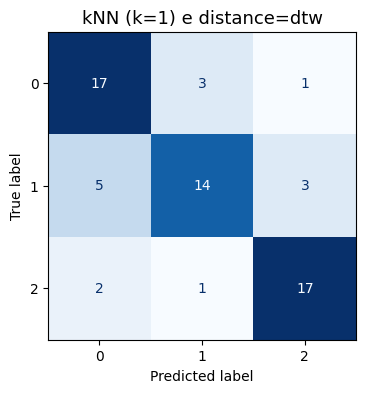

In [63]:
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier

# Dynamic Time Warping (DTW)
DISTANCIA = 'dtw'

# Treinamento do classificador
knn = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance=DISTANCIA)
knn.fit(X_train, y_train)

# Calcula a acurácia das predições
predicts = knn.predict(X_test)
print(f'Acurácia de kNN com k = 1 e distância = \'{DISTANCIA}\': {accuracy_score(y_test, predicts)}')

# Calcula a matriz de confusão
cm = confusion_matrix(y_test, predicts, labels=knn.classes_)

# Plota a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_title(f"kNN (k=1) e distance={DISTANCIA}", fontsize=13)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## <b>Avaliação com Outros Classificadores</b>

A avaliação do modelo é realizada da seguinte forma:

- função *predict()* – retorna a classe para cada exemplo de teste;

- função *predict_proba()* – retorna a probabilidade de cada classe para cada exemplo de teste;

- função *score()* – retorna a taxa de acerto (acurácia) do classificador criado recebendo como entrada a base de teste. A métrica *taxa de acerto* é usada em bases balanceadas. No caso do problema apresentar diferença significativa na quantidade de exemplos por classe, deve-se usar *f1_score()* que é a média harmônica entre precisão e revocação.

Considerando *tp (true positivive)*, *fp (false positive)* e *fn (false negative)*:

- função *precision_score()* – calcula *tp / (tp + fp)*;

- função *recall_score()* – calcula *tp / (tp + fn)*;

- função *f1_score()* – calcula a média harmônica entre *precision* e *recall*;

A função *confusion_matrix()* recebe como entrada os rótulos do teste (*y_test*) e a predição do modelo (*y_pred*). Ela retorna uma matriz CxC onde C é a quandidade de classes.
No exemplo C=10, logo uma matriz 10x10, onde na diagonal temos os acertos e nas demais posições as confusões entre as classes do problema. É usada para avaliar o classificador
apenas, mas muito importante para a análise dos erros do modelo (ou hipótese de solução para o problema).

In [64]:
def avaliar_classificador(classificador, X_test, y_test):

    # Obtém a classe predita para cada exemplo de teste
    y_pred=classificador.predict(X_test)

    # Calcula a acurácia (taxa de acerto) na base de teste (usado em bases balanceadas)
    score=classificador.score(X_test, y_test)
    print("Acurácia = %.3f " % (score * 100))

    # Calcula a precisão na base de teste
    precision=precision_score(y_test, y_pred, average='weighted')
    print("Precisão = %.3f " % precision)

    # Calcula a revocação na base de teste
    recall=recall_score(y_test, y_pred, average='weighted')
    print("Revocação = %.3f " % recall)

    # Calcula o f1_score na base de teste
    f1=f1_score(y_test, y_pred, average='weighted')
    print("Medida-F1 = %.3f " % f1)

    # Mostra o resultado previsto para a 1ª instância de teste
    print("\nA 1ª instância na base de teste foi considerada como da classe: %d" % y_pred[0])

    # Calcula e mostra a matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2])
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_title("Matriz de Confusão")
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.show()

    # Resumo das métricas
    report=classification_report(y_test, y_pred)
    print(f"\n{report}")

### <b>Árvore de Decisão</b>

Acurácia = 96.825 
Precisão = 0.971 
Revocação = 0.968 
Medida-F1 = 0.968 

A 1ª instância na base de teste foi considerada como da classe: 1


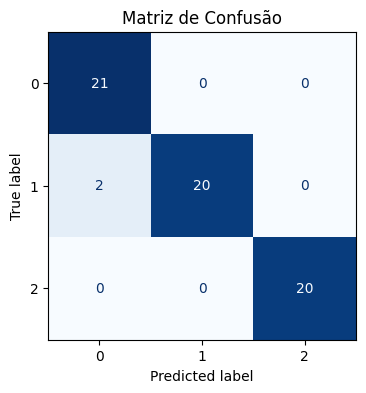


              precision    recall  f1-score   support

           0       0.91      1.00      0.95        21
           1       1.00      0.91      0.95        22
           2       1.00      1.00      1.00        20

    accuracy                           0.97        63
   macro avg       0.97      0.97      0.97        63
weighted avg       0.97      0.97      0.97        63



In [65]:
decision_tree_classifier = DecisionTreeClassifier(random_state=RANDOM_STATE)
decision_tree_classifier.fit(X_train, y_train)
avaliar_classificador(decision_tree_classifier, X_test, y_test)

### <b>kNN weighted (k = 3)</b>

Acurácia = 73.016 
Precisão = 0.737 
Revocação = 0.730 
Medida-F1 = 0.728 

A 1ª instância na base de teste foi considerada como da classe: 1


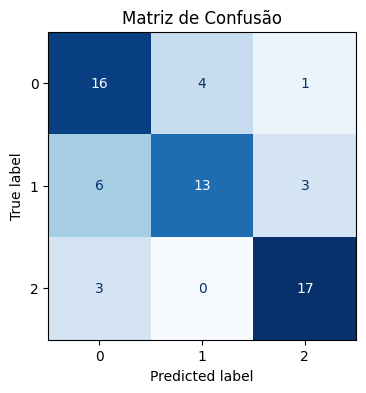


              precision    recall  f1-score   support

           0       0.64      0.76      0.70        21
           1       0.76      0.59      0.67        22
           2       0.81      0.85      0.83        20

    accuracy                           0.73        63
   macro avg       0.74      0.73      0.73        63
weighted avg       0.74      0.73      0.73        63



In [66]:
knn_weighted = KNeighborsClassifier(n_neighbors=3, weights="distance")
knn_weighted.fit(X_train, y_train)
avaliar_classificador(knn_weighted, X_test, y_test)

### <b>Naïve Bayes</b>

Acurácia = 87.302 
Precisão = 0.908 
Revocação = 0.873 
Medida-F1 = 0.869 

A 1ª instância na base de teste foi considerada como da classe: 1


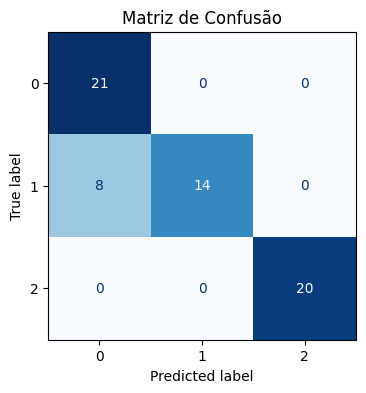


              precision    recall  f1-score   support

           0       0.72      1.00      0.84        21
           1       1.00      0.64      0.78        22
           2       1.00      1.00      1.00        20

    accuracy                           0.87        63
   macro avg       0.91      0.88      0.87        63
weighted avg       0.91      0.87      0.87        63



In [67]:
naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train)
avaliar_classificador(naive_bayes, X_test, y_test)

### <b>SVM</b>

Acurácia = 46.032 
Precisão = 0.499 
Revocação = 0.460 
Medida-F1 = 0.422 

A 1ª instância na base de teste foi considerada como da classe: 1


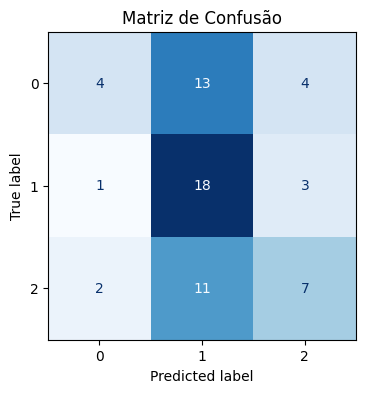


              precision    recall  f1-score   support

           0       0.57      0.19      0.29        21
           1       0.43      0.82      0.56        22
           2       0.50      0.35      0.41        20

    accuracy                           0.46        63
   macro avg       0.50      0.45      0.42        63
weighted avg       0.50      0.46      0.42        63



In [68]:
svc = SVC(probability=True, random_state=RANDOM_STATE)
svc.fit(X_train, y_train)
avaliar_classificador(svc, X_test, y_test)

### <b>Ensemble – Random Forest</b>

Acurácia = 92.063 
Precisão = 0.936 
Revocação = 0.921 
Medida-F1 = 0.920 

A 1ª instância na base de teste foi considerada como da classe: 0


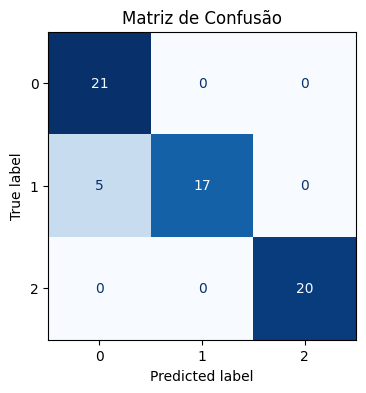


              precision    recall  f1-score   support

           0       0.81      1.00      0.89        21
           1       1.00      0.77      0.87        22
           2       1.00      1.00      1.00        20

    accuracy                           0.92        63
   macro avg       0.94      0.92      0.92        63
weighted avg       0.94      0.92      0.92        63



In [69]:
ensemble_rf = RandomForestClassifier(random_state=RANDOM_STATE)
ensemble_rf.fit(X_train, y_train)
avaliar_classificador(ensemble_rf, X_test, y_test)

### <b>Ensemble – VotingClassifier (hard) – Voto Majoritário</b>

Acurácia = 74.603 
Precisão = 0.808 
Revocação = 0.746 
Medida-F1 = 0.718 

A 1ª instância na base de teste foi considerada como da classe: 1


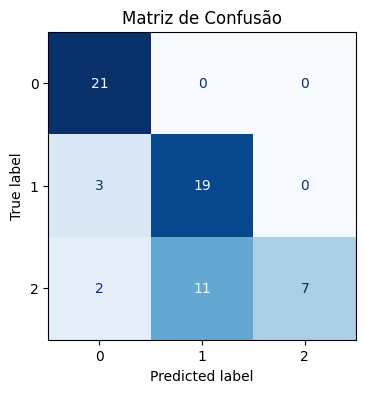


              precision    recall  f1-score   support

           0       0.81      1.00      0.89        21
           1       0.63      0.86      0.73        22
           2       1.00      0.35      0.52        20

    accuracy                           0.75        63
   macro avg       0.81      0.74      0.71        63
weighted avg       0.81      0.75      0.72        63



In [70]:
ensemble_vc_hard = VotingClassifier(estimators=[
    ("DT", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ("SVM", SVC(probability=True, random_state=RANDOM_STATE))
])
ensemble_vc_hard.fit(X_train, y_train)
avaliar_classificador(ensemble_vc_hard, X_test, y_test)

### <b>Avaliação de classificadores com os seguintes atributos:</b>
* **Acelerômetro**:
  * ax_media; ax_std; ax_amplitude; ax_rms; ax_mediana; ax_energia;
  * ay_media; ay_std; ay_amplitude; ay_rms; ay_mediana; ay_energia;
  * az_media; az_std; az_amplitude; az_rms; az_mediana; az_energia;
* **Giroscópio**:
  * gx_media; gx_std; gx_amplitude; gx_rms; gx_mediana; gx_energia;
  * gy_media; gy_std; gy_amplitude; gy_rms; gy_mediana; gy_energia;
  * gz_media; gz_std; gz_amplitude; gz_rms; gz_mediana; gz_energia;
* classe – rótulo do gesto: 0 (esquerda), 1 (direita) e 2 (cima).


In [71]:
# Carrega a base de dados
df_ = pd.read_csv(URL_BASE_DADOS, sep=';')

# Remove as colunas desconsideradas no contexto de estudo
df_.drop([
  "ax_min", "ax_max", "ay_min", "ay_max", "az_min", "az_max",
  "gx_min", "gx_max", "gy_min", "gy_max", "gz_min", "gz_max",
  "gesto", "nome_classe", "duracao", "numero_amostras"
], axis=1, inplace=True)

# Separa atributos de entrada em X e as classes em y
X_ = df_.iloc[:,0:36]
y_ = df_.iloc[:,36]

print("Formato de X: ", X.shape)
print("Formato de y: ", y.shape)

Formato de X:  (210, 48)
Formato de y:  (210,)


## <b>Nova divisão da base em treinamento e teste</b>
Divisão da base em duas partes: treinamento (70%) e teste (30%).

In [72]:
X_train_, X_test_, y_train_, y_test_ = train_test_split(X_, y_, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

print("Formato de X_train_: ", X_train_.shape)
print("Formato de y_train_: ", y_train_.shape)
print()
print("Formato de X_test_: ", X_test_.shape)
print("Formato de y_test_: ", y_test_.shape)
print()
print(f'Nº de observações por série: {X_train_.shape[1]}.')
print(f'Nº de classes do problema {np.unique(y_train_)}.')

Formato de X_train_:  (147, 36)
Formato de y_train_:  (147,)

Formato de X_test_:  (63, 36)
Formato de y_test_:  (63,)

Nº de observações por série: 36.
Nº de classes do problema [0 1 2].


### <b>Árvore de Decisão (nova base de treinamento e teste)</b>

Acurácia = 96.825 
Precisão = 0.971 
Revocação = 0.968 
Medida-F1 = 0.968 

A 1ª instância na base de teste foi considerada como da classe: 1


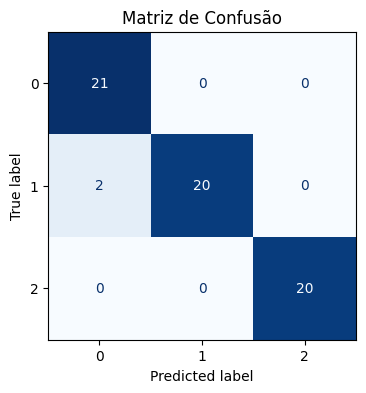


              precision    recall  f1-score   support

           0       0.91      1.00      0.95        21
           1       1.00      0.91      0.95        22
           2       1.00      1.00      1.00        20

    accuracy                           0.97        63
   macro avg       0.97      0.97      0.97        63
weighted avg       0.97      0.97      0.97        63



In [73]:
decision_tree_classifier_ = DecisionTreeClassifier(random_state=RANDOM_STATE)
decision_tree_classifier_.fit(X_train_, y_train_)
avaliar_classificador(decision_tree_classifier_, X_test_, y_test_)

### <b>kNN weighted (k = 3) (nova base de treinamento e teste)</b>

Acurácia = 73.016 
Precisão = 0.737 
Revocação = 0.730 
Medida-F1 = 0.728 

A 1ª instância na base de teste foi considerada como da classe: 1


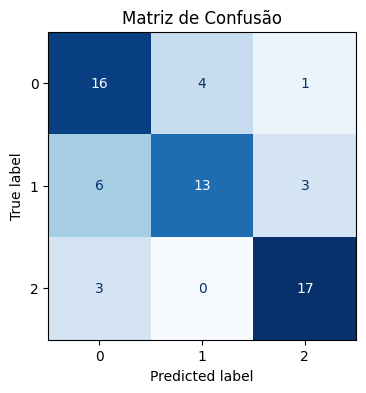


              precision    recall  f1-score   support

           0       0.64      0.76      0.70        21
           1       0.76      0.59      0.67        22
           2       0.81      0.85      0.83        20

    accuracy                           0.73        63
   macro avg       0.74      0.73      0.73        63
weighted avg       0.74      0.73      0.73        63



In [74]:
knn_weighted_ = KNeighborsClassifier(n_neighbors=3, weights="distance")
knn_weighted_.fit(X_train_, y_train_)
avaliar_classificador(knn_weighted_, X_test_, y_test_)

### <b>SVM (nova base de treinamento e teste)</b>

Acurácia = 49.206 
Precisão = 0.538 
Revocação = 0.492 
Medida-F1 = 0.467 

A 1ª instância na base de teste foi considerada como da classe: 1


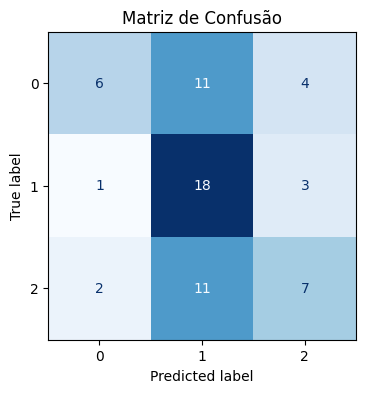


              precision    recall  f1-score   support

           0       0.67      0.29      0.40        21
           1       0.45      0.82      0.58        22
           2       0.50      0.35      0.41        20

    accuracy                           0.49        63
   macro avg       0.54      0.48      0.46        63
weighted avg       0.54      0.49      0.47        63



In [75]:
svc_ = SVC(probability=True, random_state=RANDOM_STATE)
svc_.fit(X_train_, y_train_)
avaliar_classificador(svc_, X_test_, y_test_)